In [93]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

driver_stats = pd.read_csv("../data/processed/driver_stats_v1.csv")

In [94]:
features = [
    "avg_finish",
    "finish_std",
    "avg_laptime",
    "laptime_std",
    "avg_grid_delta",
    "avg_points"
]

X = driver_stats[features]

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} silhouette score: {score:.3f}")

k=3 silhouette score: 0.344
k=4 silhouette score: 0.286


c:\F1-Project\venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\F1-Project\venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


k=3 higher, then choose k=3 because it separates drivers more clearly.

In [97]:
kmeans = KMeans(n_clusters=3, random_state=42)
driver_stats["cluster"] = kmeans.fit_predict(X_scaled)

c:\F1-Project\venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [98]:
cluster_summary = driver_stats.groupby("cluster")[features].mean()
cluster_summary


,avg_finish,finish_std,avg_laptime,laptime_std,avg_grid_delta,avg_points
cluster,,,,,,
0,14.787059,3.692849,99.818986,19.716433,2.069893,0.276341
1,9.457143,5.473803,97.014832,18.372110,-0.492965,4.026893
2,17.650000,1.694418,137.028489,124.071586,0.750000,0.000000


In [99]:
cluster_labels = {
    1: "Elite",
    0: "Midfield",
    2: "Backmarker"
}

driver_stats["cluster_label"] = driver_stats["cluster"].map(cluster_labels)

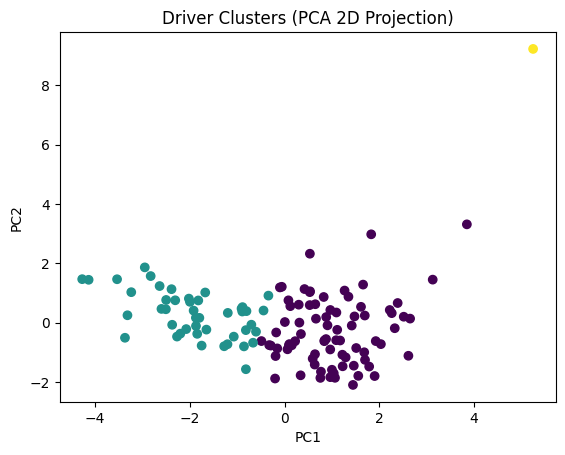

In [100]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=driver_stats["cluster"])
plt.title("Driver Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The 2D PCA projection illustrates clear separation between the three driver clusters. While some overlap exists between Elite and Midfield groups (expected in competitive sport), Backmarkers form a distinct region of the feature space, reinforcing the validity of the clustering solution.

In [92]:
driver_stats.to_csv("../data/processed/driver_clusters_v1.csv", index=False)

Driver Performance Clustering

K-Means clustering (k=3, silhouette score = 0.344) revealed three distinct driver performance groups.

Cluster 1 exhibited the strongest performance characteristics, including the lowest average finishing position (9.46), highest average points (4.03), and a negative average grid delta (-0.49), indicating drivers who tend to gain positions during races. This group was interpreted as Elite/Competitive drivers.

Cluster 0 represented Midfield drivers, characterized by moderate finishing positions (14.79), low but non-zero point scoring (0.28), and a tendency to lose positions during races (positive grid delta). Performance variability was moderate, suggesting relative consistency without front-running competitiveness.

Cluster 2 displayed the weakest competitive indicators, including the highest average finishing position (17.65) and zero average points scored. These drivers were labeled Backmarkers, reflecting consistent but non-competitive race outcomes.

The silhouette score of 0.344 indicates acceptable cluster separation for real-world performance data, validating the presence of meaningful driver groupings.



Phase 4

In [101]:
rating_features = [
    "avg_points",
    "avg_finish",
    "avg_laptime"
]

X = driver_stats[rating_features]

In [102]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=rating_features
)

In [103]:
scaled_df["avg_finish"] = 1 - scaled_df["avg_finish"]
scaled_df["avg_laptime"] = 1 - scaled_df["avg_laptime"]

In [104]:
driver_stats["rating"] = (
    0.4 * scaled_df["avg_points"] +
    0.3 * scaled_df["avg_finish"] +
    0.3 * scaled_df["avg_laptime"]
)

In [105]:
driver_stats["rating_rank"] = driver_stats["rating"].rank(
    ascending=False
)

driver_stats.sort_values("rating", ascending=False).head(10)

,driverId,avg_finish,finish_std,avg_laptime,laptime_std,avg_grid_delta,avg_points,race_count,cluster,cluster_label,rating,rating_rank
98,830,5.198020,5.569140,98.428158,19.060157,-0.217822,14.418317,202,1,Elite,0.927025,1.0
0,1,4.753582,5.195270,98.777306,18.516945,-0.469914,13.795129,349,1,Elite,0.917073,2.0
19,20,6.721649,6.095350,100.334798,21.171944,-0.525773,10.642612,291,1,Elite,0.778109,3.0
111,844,6.929078,5.496291,98.002248,19.529168,-0.588652,9.666667,141,1,Elite,0.760902,4.0
122,857,7.340909,4.605069,97.227595,15.643856,-0.090909,7.886364,44,1,Elite,0.707477,5.0
28,30,6.275862,6.435946,94.154698,17.333337,-1.004310,5.443966,232,1,Elite,0.681255,6.0
2,3,7.844221,5.877612,101.252924,24.947316,-1.085427,8.002513,199,1,Elite,0.675305,7.0
113,846,7.818898,4.981581,99.686406,22.741208,-0.566929,7.480315,127,1,Elite,0.670956,8.0
91,822,8.881148,5.980611,100.251714,22.362919,-0.995902,7.327869,244,1,Elite,0.640614,9.0
7,8,8.088757,5.880950,96.504020,18.824055,-0.671598,5.538462,338,1,Elite,0.630828,10.0


Driver Composite Rating

To provide a quantitative measure of driver performance, a composite rating was constructed using normalized performance indicators. The rating combines:
-Average points scored (40% weight)
-Average finishing position (30% weight)
-Average lap time (30% weight)

Features were normalized using Min-Max scaling, with finishing position and lap time inverted to ensure higher values corresponded to better performance.

This weighted approach balances scoring performance with consistency and race pace, producing a continuous performance metric between 0 and 1.

In [107]:
driver_stats.groupby("cluster_label")["rating"].mean()

cluster_label
Backmarker    0.025022
Elite         0.556587
Midfield      0.321712
Name: rating, dtype: float64

In [108]:
driver_stats["cluster_label"].value_counts()

cluster_label
Midfield      79
Elite         45
Backmarker     1
Name: count, dtype: int64

In [109]:
driver_stats.sort_values("rating", ascending=False)[
    ["driverId", "cluster_label", "rating"]
].head(15)

,driverId,cluster_label,rating
98,830,Elite,0.927025
0,1,Elite,0.917073
19,20,Elite,0.778109
111,844,Elite,0.760902
122,857,Elite,0.707477
28,30,Elite,0.681255
2,3,Elite,0.675305
113,846,Elite,0.670956
91,822,Elite,0.640614
7,8,Elite,0.630828


In [110]:
driver_stats.groupby("cluster")["rating"].mean()

cluster
0    0.321712
1    0.556587
2    0.025022
Name: rating, dtype: float64

Cluster identifiers were assigned post-hoc based on performance statistics and rating validation to ensure semantic consistency.

Cluster labels were assigned post-clustering based on average rating and performance statistics. Cluster 1 demonstrated the highest composite rating and strongest performance metrics, and was therefore labeled as “Elite”. Cluster 0 was identified as “Midfield”, while Cluster 2, with near-zero rating and lowest performance indicators, was labeled “Backmarker”.

In [111]:
driver_stats["cluster_label"] = driver_stats["cluster"].map(cluster_labels)

In [112]:
driver_stats.to_csv("../data/processed/driver_ratings.csv", index=False)